<center><h1>Xiaoyun_Tang_HW2</h1></center>
<br>
<br>

Name: Xiaoyun Tang
<br>
Github Username: yuanjiujiu099
<br>
USC ID: 3843547131

## 1. Combined Cycle Power Plant Data Set

### (a) Download Data

Package imports

In [34]:
import pandas as pd

In [35]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


Get the Cycle Power Plant Data Set

In [36]:
import pandas as pd
import zipfile

zip_path = "../data/Homework 2 Data.zip"

with zipfile.ZipFile(zip_path) as archive:
    with archive.open("CCPP/Folds5x2_pp.xlsx") as excel_file:
        df = pd.read_excel(excel_file, sheet_name="Sheet1")

df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


### (b) Exploring the data

#### i. rows and columns

In [37]:
rows = df.shape[0]
columns = df.shape[1]

print("Number of rows:", rows)
print("Number of columns:", columns)

Number of rows: 9568
Number of columns: 5


The dataset has 9,568 rows and 5 columns. Each row represents an hourly average observation from the power plant. The four predictors are ambient temperature (AT), exhaust vacuum (V), ambient pressure (AP), and relative humidity (RH). The response is electrical power output (PE)

#### ii. pairwise scatterplots of all the varianbles

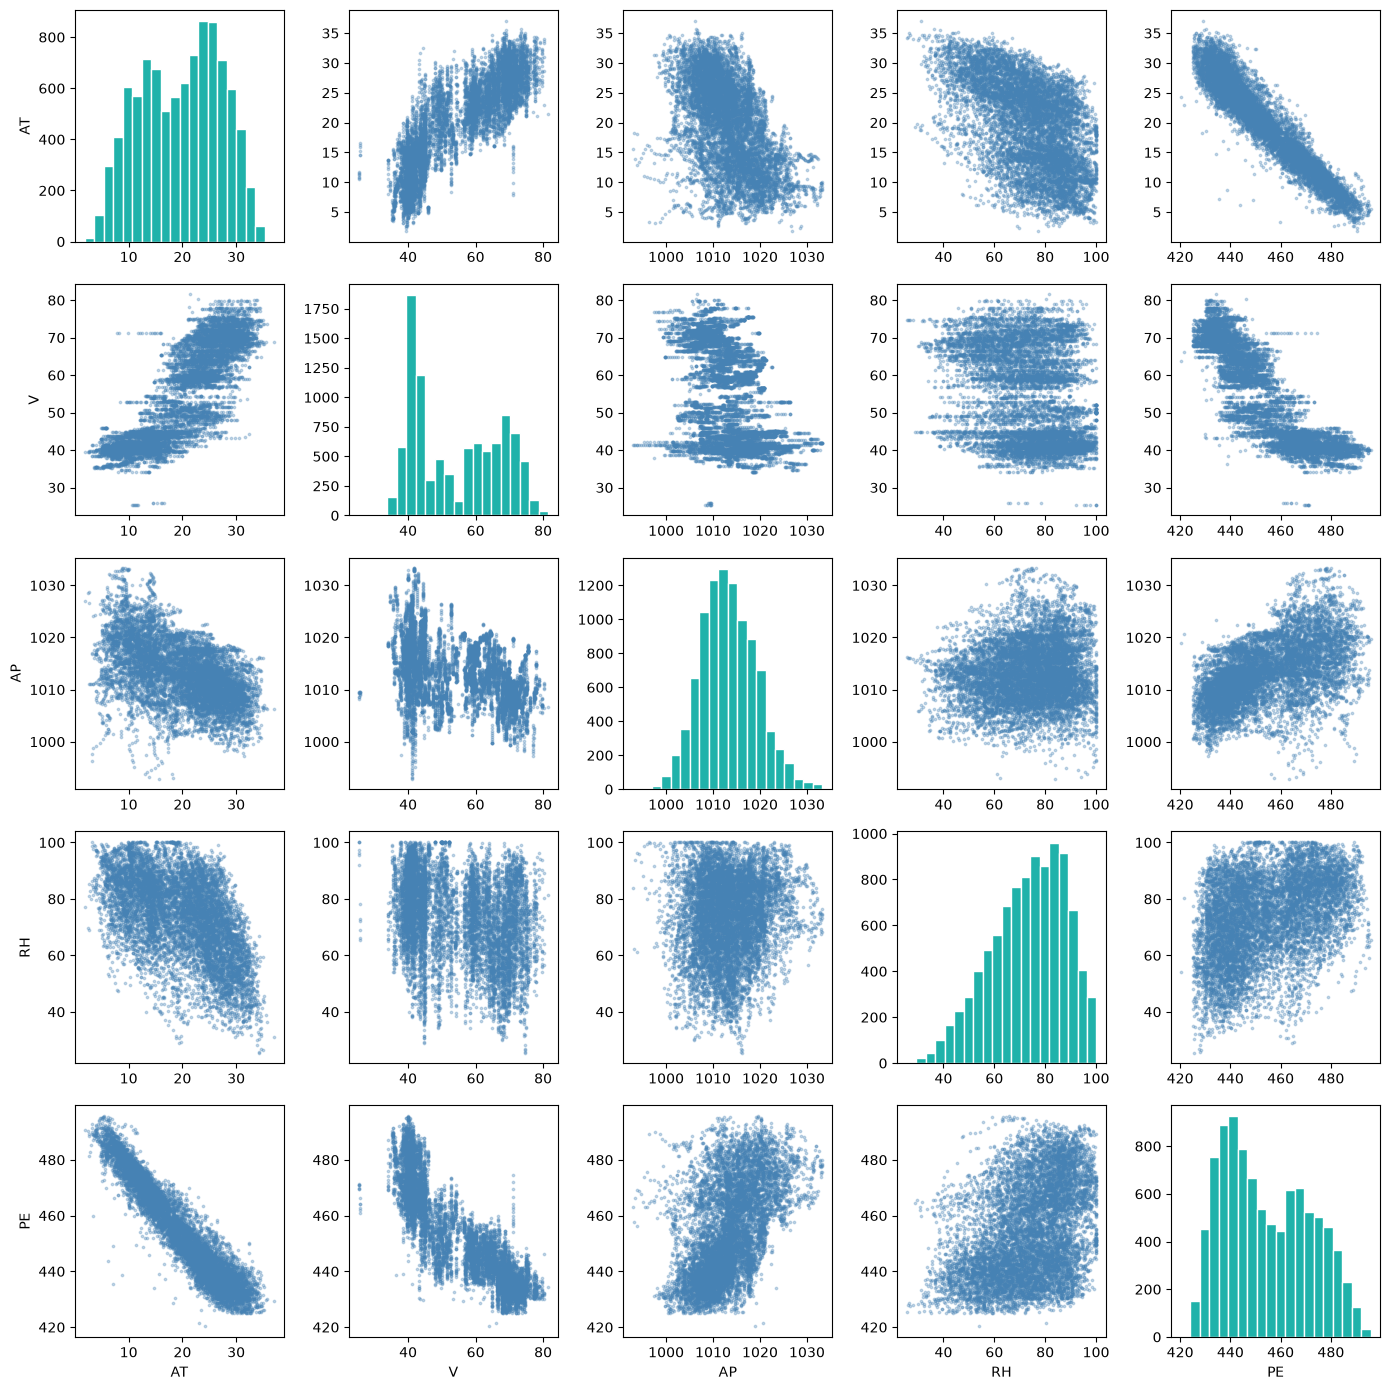

In [38]:
import matplotlib.pyplot as plt

variables = ["AT", "V", "AP", "RH", "PE"]

plt.figure(figsize=(14, 14))

for i in range(5):
    for j in range(5):
        plt.subplot(5, 5, i * 5 + j + 1)

        if i == j:
            plt.hist(df[variables[i]], bins=20,
                     color="lightseagreen", edgecolor="white")
        else:
            plt.scatter(df[variables[j]], df[variables[i]],
                        s=3, alpha=0.3, color="steelblue")

        if i == 4:
            plt.xlabel(variables[j])

        if j == 0:
            plt.ylabel(variables[i])

plt.tight_layout()
plt.show()

PE decreases as AT and V increase, while its positive relationships with AP and RH are weaker. The predictors also show relationships with one another. For example, AT and V have a clear positive relationship, while AT and AP show a negative trend.

#### iii. mean, the median, range, first and third quartiles, and interquartile ranges

In [39]:
variables = ["AT", "V", "AP", "RH", "PE"]

summary = pd.DataFrame()

for variable in variables:
    data = df[variable]

    summary.loc[variable, "Mean"] = data.mean()
    summary.loc[variable, "Median"] = data.median()
    summary.loc[variable, "Range"] = data.max() - data.min()
    summary.loc[variable, "Q1"] = data.quantile(0.25)
    summary.loc[variable, "Q3"] = data.quantile(0.75)
    summary.loc[variable, "IQR"] = data.quantile(0.75) - data.quantile(0.25)

summary.round(2)

,Mean,Median,Range,Q1,Q3,IQR
AT,19.65,20.34,35.30,13.51,25.72,12.21
V,54.31,52.08,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,74.60,63.33,84.83,21.50
PE,454.37,451.55,75.50,439.75,468.43,28.68


The table summarizes the six descriptive statistics for all five variables. AT has a mean of 19.65 and a median of 20.34. Its middle 50% of observations lie between 13.51 and 25.72, giving an IQR of 12.21. PE has a mean of 454.37, and its middle 50% of observations lie between 439.75 and 468.43.

### (c) Simple Linear Regression

In [40]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [41]:
import statsmodels.formula.api as smf

model = smf.ols("PE ~ AT", data=df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:11:17   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

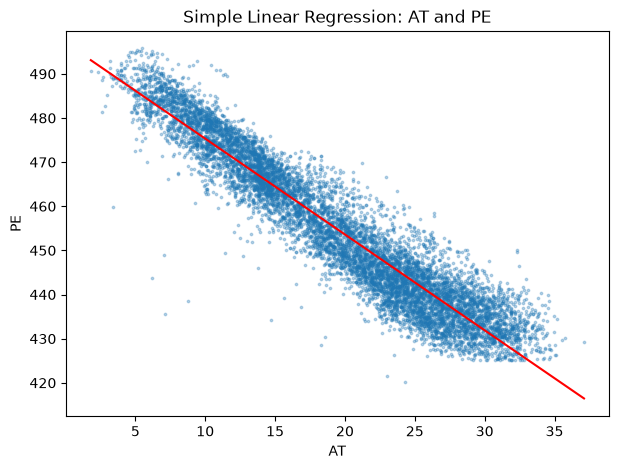

In [42]:
plt.figure(figsize=(7, 5))

plt.scatter(df["AT"], df["PE"], s=3, alpha=0.3)

x = [df["AT"].min(), df["AT"].max()]
y = model.predict(pd.DataFrame({"AT": x}))

plt.plot(x, y, color="red")

plt.xlabel("AT")
plt.ylabel("PE")
plt.title("Simple Linear Regression: AT and PE")
plt.show()

In [43]:
predictors = ["AT", "V", "AP", "RH"]

simple_results = pd.DataFrame()

for variable in predictors:
    model = smf.ols("PE ~ " + variable, data=df).fit()

    simple_results.loc[variable, "Intercept"] = model.params["Intercept"]
    simple_results.loc[variable, "Slope"] = model.params[variable]
    simple_results.loc[variable, "P-value"] = model.pvalues[variable]
    simple_results.loc[variable, "R-squared"] = model.rsquared

simple_results

,Intercept,Slope,P-value,R-squared
AT,497.034120,-2.171320,0.0,0.898948
V,517.801526,-1.168135,0.0,0.756518
AP,-1055.260989,1.489872,0.0,0.268769
RH,420.961766,0.455650,0.0,0.151939


In the separate simple linear regressions, higher AT and V are associated with lower PE, while higher AP and RH are associated with higher PE. All four slopes are statistically significant because their p-values are very small. AT gives the best fit, with an R² of about 0.899, followed by V at 0.757. AP and RH have much lower R² values, so they explain less of the variation in PE on their own.

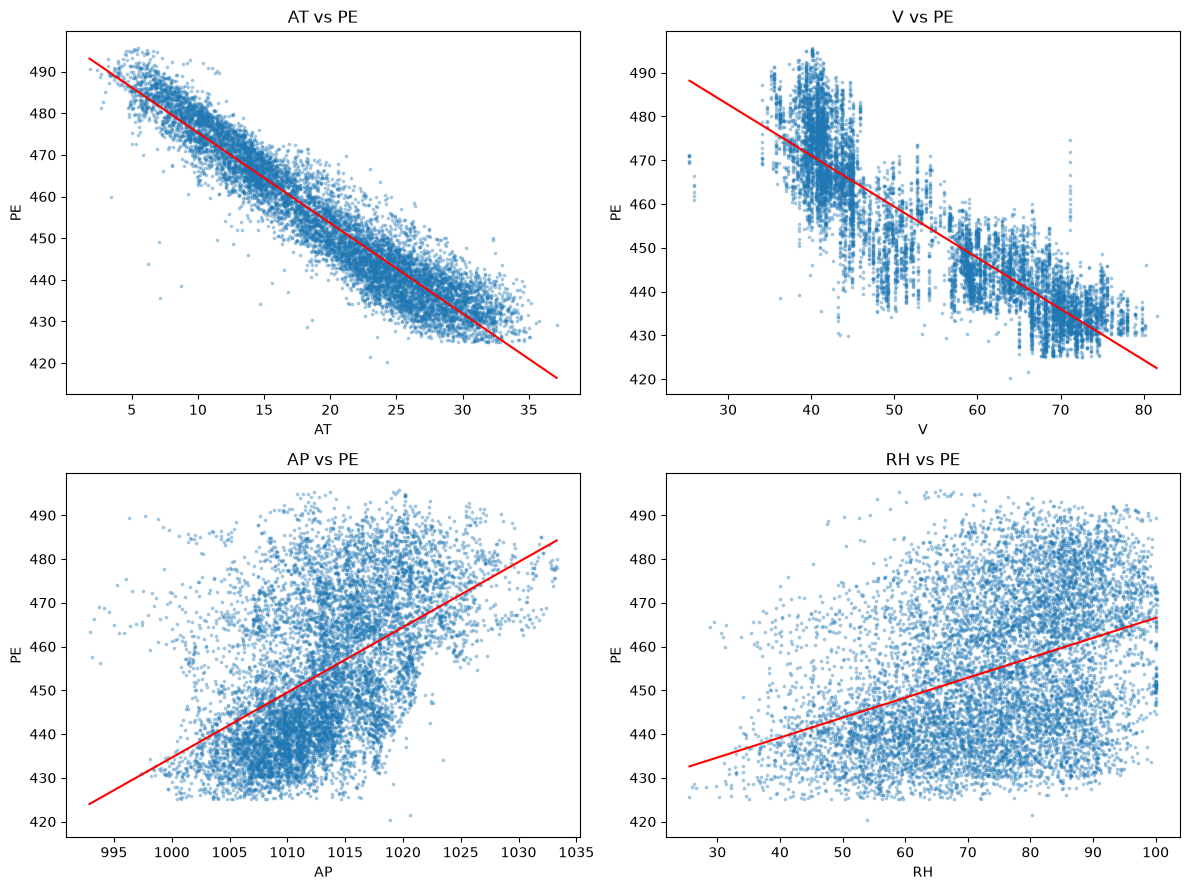

In [44]:
predictors = ["AT", "V", "AP", "RH"]

plt.figure(figsize=(12, 9))

for i in range(4):
    variable = predictors[i]
    model = smf.ols("PE ~ " + variable, data=df).fit()

    plt.subplot(2, 2, i + 1)
    plt.scatter(df[variable], df["PE"], s=3, alpha=0.3)

    x = [df[variable].min(), df[variable].max()]
    y = model.predict(pd.DataFrame({variable: x}))

    plt.plot(x, y, color="red")
    plt.xlabel(variable)
    plt.ylabel("PE")
    plt.title(variable + " vs PE")

plt.tight_layout()
plt.show()

AT shows a clear downward trend, with points fairly close to the regression line. V also has a negative relationship with PE, but its points are more spread out. AP and RH show positive trends, although the points are widely scattered around the lines. These plots agree with the R² values: AT fits best, followed by V, while AP and RH give weaker fits.

Some observations lie far from the fitted lines. To investigate potential outliers, I flag observations whose internally studentized residuals exceed 3 in absolute value. Residuals and influence measures would help determine whether any points need further investigation. I kept all observations in all four regression models.

In [45]:
outlier_results = []

for variable in predictors:
    fitted_model = smf.ols(f"PE ~ {variable}", data=df).fit()
    residuals = fitted_model.get_influence().resid_studentized_internal

    outlier_results.append({
        "Predictor": variable,
        "Observations with |studentized residual| > 3":
            int((abs(residuals) > 3).sum())
    })

pd.DataFrame(outlier_results)

,Predictor,Observations with |studentized residual| > 3
0,AT,42
1,V,33
2,AP,29
3,RH,2


Observations with large studentized residuals are flagged for investigation rather than automatically removed. A large residual alone does not establish a recording error. I therefore retain all observations and acknowledge that some may influence the fitted models.

### (d) Multiple Regression

In [46]:
multiple_model = smf.ols("PE ~ AT + V + AP + RH", data=df).fit()

print(multiple_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:11:17   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

The multiple regression model has an R² of 0.929, compared with 0.899 for AT alone. All four predictors are statistically significant at the 0.05 level. Holding the other predictors constant, AT, V, and RH have negative coefficients, while AP has a positive coefficient.

### (e) 1c Compare to 1d

In [47]:
predictors = ["AT", "V", "AP", "RH"]

comparison = pd.DataFrame()

for variable in predictors:
    comparison.loc[variable, "Simple"] = simple_results.loc[variable, "Slope"]
    comparison.loc[variable, "Multiple"] = multiple_model.params[variable]

comparison

,Simple,Multiple
AT,-2.171320,-1.977513
V,-1.168135,-0.233916
AP,1.489872,0.062083
RH,0.455650,-0.158054


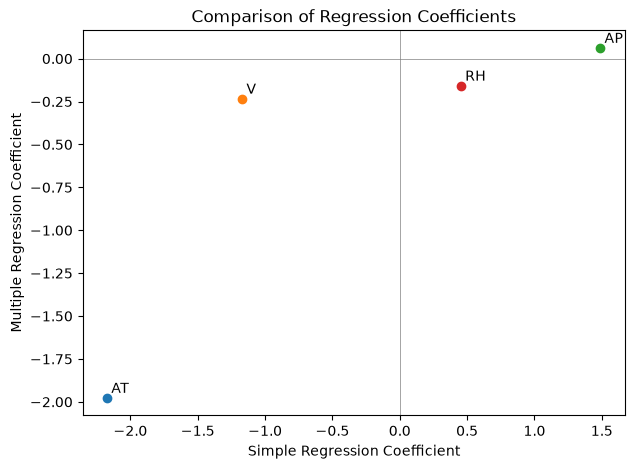

In [48]:
plt.figure(figsize=(7, 5))

for variable in predictors:
    x = comparison.loc[variable, "Simple"]
    y = comparison.loc[variable, "Multiple"]

    plt.scatter(x, y)
    plt.text(x + 0.03, y + 0.03, variable)

plt.axhline(0, color="gray", linewidth=0.5)
plt.axvline(0, color="gray", linewidth=0.5)

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Comparison of Regression Coefficients")
plt.show()

All four coefficients become smaller in magnitude in the multiple regression. AT changes relatively little, while V and AP move much closer to zero. RH changes from positive to negative. These differences arise because multiple regression accounts for the other predictors.

### (f) Nonlinear Association

In [49]:
nonlinear_model = smf.ols(
    "PE ~ AT + I(AT ** 2) + I(AT ** 3)",
    data=df
).fit()

print(nonlinear_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:11:17   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

In [50]:
linear_model = smf.ols("PE ~ AT", data=df).fit()

f_stat, p_value, df_diff = nonlinear_model.compare_f_test(linear_model)

print("P-value for nonlinear terms:", p_value)

P-value for nonlinear terms: 3.478379154353575e-285


For AT, the joint test of the quadratic and cubic terms gives a p-value below 0.05, providing evidence of a nonlinear relationship with PE. The R² increases from 0.899 to 0.912.

In [51]:
predictors = ["AT", "V", "AP", "RH"]

nonlinear_results = pd.DataFrame()

for variable in predictors:
    temp = pd.DataFrame()
    temp["PE"] = df["PE"]
    temp["x"] = df[variable] - df[variable].mean()

    linear_model = smf.ols("PE ~ x", data=temp).fit()

    nonlinear_model = smf.ols(
        "PE ~ x + I(x ** 2) + I(x ** 3)",
        data=temp
    ).fit()

    f_stat, p_value, df_diff = nonlinear_model.compare_f_test(linear_model)

    nonlinear_results.loc[variable, "Linear R-squared"] = linear_model.rsquared
    nonlinear_results.loc[variable, "Cubic R-squared"] = nonlinear_model.rsquared
    nonlinear_results.loc[variable, "Nonlinear P-value"] = p_value

nonlinear_results

,Linear R-squared,Cubic R-squared,Nonlinear P-value
AT,0.898948,0.911883,3.478379e-285
V,0.756518,0.775022,7.040304e-165
AP,0.268769,0.297543,4.209145e-84
RH,0.151939,0.153743,3.799622e-05


All four predictors show evidence of a nonlinear relationship with PE, since the joint-test p-values are below 0.05. AP has the largest increase in R², from 0.269 to 0.298, while RH changes very little.

### (g) Interactions of Predictors

In [52]:
interaction_model = smf.ols(
    "PE ~ AT + V + AP + RH"
    " + AT:V + AT:AP + AT:RH"
    " + V:AP + V:RH + AP:RH",
    data=df
).fit()

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:11:17   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

AT×V, AT×RH, V×AP, and AP×RH are significant at the 0.05 level, providing evidence of interaction effects. AT×AP and V×RH are not significant. Adding the interactions increases R² from 0.929 to 0.936.

### (h) Improvement

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

train_data, test_data = train_test_split(
    df, test_size=0.3, random_state=42
)

print("Training rows:", len(train_data))
print("Test rows:", len(test_data))

Training rows: 6697
Test rows: 2871


In [54]:
basic_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_data
).fit()

train_predictions = basic_model.predict(train_data)
test_predictions = basic_model.predict(test_data)

train_mse = mean_squared_error(train_data["PE"], train_predictions)
test_mse = mean_squared_error(test_data["PE"], test_predictions)

print("Training MSE:", train_mse)
print("Test MSE:", test_mse)

Training MSE: 20.580839725738695
Test MSE: 21.239856938225554


In [55]:
full_model = smf.ols(
    "PE ~ AT + V + AP + RH"
    " + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
    " + AT:V + AT:AP + AT:RH + V:AP + V:RH + AP:RH",
    data=train_data
).fit()

print(full_model.summary())
print(full_model.pvalues.to_string())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:11:17   Log-Likelihood:                -19160.
No. Observations:                6697   AIC:                         3.835e+04
Df Residuals:                    6682   BIC:                         3.845e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7664.9809   1429.568     -5.362      0.0

In [56]:
reduced_model = smf.ols(
    "PE ~ AT + V + AP + RH"
    " + I(AT ** 2) + I(V ** 2) + I(AP ** 2) + I(RH ** 2)"
    " + AT:V + AT:AP + AT:RH + V:AP + AP:RH",
    data=train_data
).fit()

print(reduced_model.pvalues.to_string())

Intercept     7.774748e-08
AT            4.252926e-02
V             2.257453e-01
AP            8.621179e-09
RH            9.671985e-05
I(AT ** 2)    2.120525e-10
I(V ** 2)     6.077328e-01
I(AP ** 2)    7.708529e-09
I(RH ** 2)    4.135297e-12
AT:V          5.938202e-05
AT:AP         1.983518e-01
AT:RH         1.499480e-08
V:AP          3.397443e-01
AP:RH         2.074300e-04


In [57]:
reduced_model = smf.ols(
    "PE ~ AT + V + AP + RH"
    " + I(AT ** 2) + I(AP ** 2) + I(RH ** 2)"
    " + AT:V + AT:AP + AT:RH + V:AP + AP:RH",
    data=train_data
).fit()

print(reduced_model.pvalues.to_string())

Intercept     7.239530e-08
AT            3.945875e-02
V             2.331686e-01
AP            8.030646e-09
RH            8.730734e-05
I(AT ** 2)    2.406817e-13
I(AP ** 2)    7.235847e-09
I(RH ** 2)    2.666222e-12
AT:V          3.433734e-08
AT:AP         1.845414e-01
AT:RH         8.337728e-09
V:AP          3.578255e-01
AP:RH         1.905694e-04


Using a 0.05 cutoff, I removed V:RH, V², and V:AP one at a time, refitting after each removal. I kept the main effects needed for the remaining interaction and quadratic terms.

In [58]:
reduced_model = smf.ols(
    "PE ~ AT + V + AP + RH"
    " + I(AT ** 2) + I(AP ** 2) + I(RH ** 2)"
    " + AT:V + AT:AP + AT:RH + AP:RH",
    data=train_data
).fit()

print(reduced_model.pvalues.to_string())

Intercept     1.026340e-07
AT            2.345160e-05
V             4.323325e-46
AP            1.173291e-08
RH            1.355065e-04
I(AT ** 2)    5.853797e-16
I(AP ** 2)    1.073202e-08
I(RH ** 2)    2.022482e-12
AT:V          1.547742e-08
AT:AP         1.507773e-03
AT:RH         9.794066e-09
AP:RH         2.974884e-04


In [59]:
results = pd.DataFrame()

results.loc["Basic", "Train MSE"] = mean_squared_error(
    train_data["PE"], basic_model.predict(train_data)
)
results.loc["Basic", "Test MSE"] = mean_squared_error(
    test_data["PE"], basic_model.predict(test_data)
)

results.loc["Reduced", "Train MSE"] = mean_squared_error(
    train_data["PE"], reduced_model.predict(train_data)
)
results.loc["Reduced", "Test MSE"] = mean_squared_error(
    test_data["PE"], reduced_model.predict(test_data)
)

results.round(3)

,Train MSE,Test MSE
Basic,20.581,21.24
Reduced,17.891,18.66


After adding quadratic and interaction terms and removing insignificant terms, the training MSE decreased from 20.581 to 17.891, and the test MSE decreased from 21.240 to 18.660. The reduced model lowered the test MSE by about 12.1%, showing better prediction performance on this test split. The significance of a term can change after other terms are removed. AT:AP becomes significant in the final model, so it is retained.

### (i) KNN

In [60]:
from sklearn.neighbors import KNeighborsRegressor

predictors = ["AT", "V", "AP", "RH"]

X_train = train_data[predictors]
X_test = test_data[predictors]

y_train = train_data["PE"]
y_test = test_data["PE"]

train_errors = []
test_errors = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)

    train_predictions = knn.predict(X_train)
    test_predictions = knn.predict(X_test)

    train_errors.append(mean_squared_error(y_train, train_predictions))
    test_errors.append(mean_squared_error(y_test, test_predictions))

In [61]:
best_test_mse = min(test_errors)
best_k = test_errors.index(best_test_mse) + 1

print("Best K:", best_k)
print("Training MSE:", train_errors[best_k - 1])
print("Test MSE:", best_test_mse)

Best K: 5
Training MSE: 10.600768887561596
Test MSE: 15.726819842563568


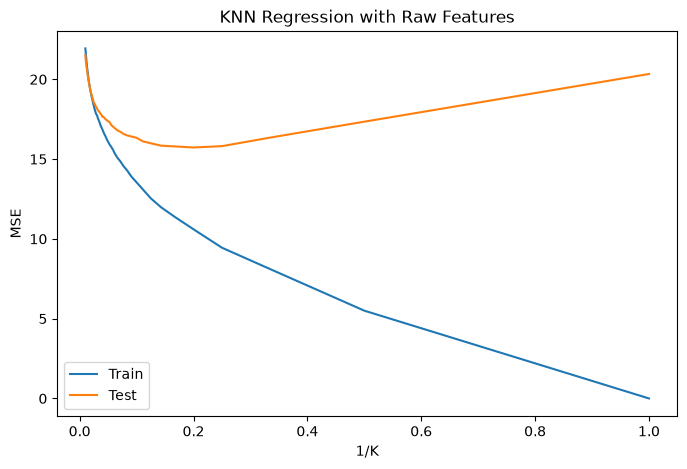

In [62]:
inverse_k = []

for k in range(1, 101):
    inverse_k.append(1 / k)

plt.figure(figsize=(8, 5))

plt.plot(inverse_k, train_errors, label="Train")
plt.plot(inverse_k, test_errors, label="Test")

plt.xlabel("1/K")
plt.ylabel("MSE")
plt.title("KNN Regression with Raw Features")
plt.legend()
plt.show()

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [64]:
train_errors_scaled = []
test_errors_scaled = []

for k in range(1, 101):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    train_predictions = knn.predict(X_train_scaled)
    test_predictions = knn.predict(X_test_scaled)

    train_errors_scaled.append(
        mean_squared_error(y_train, train_predictions)
    )
    test_errors_scaled.append(
        mean_squared_error(y_test, test_predictions)
    )

best_test_mse_scaled = min(test_errors_scaled)
best_k_scaled = test_errors_scaled.index(best_test_mse_scaled) + 1

print("Best K:", best_k_scaled)
print("Training MSE:", train_errors_scaled[best_k_scaled - 1])
print("Test MSE:", best_test_mse_scaled)

Best K: 4
Training MSE: 8.454347681797822
Test MSE: 14.291333431295715


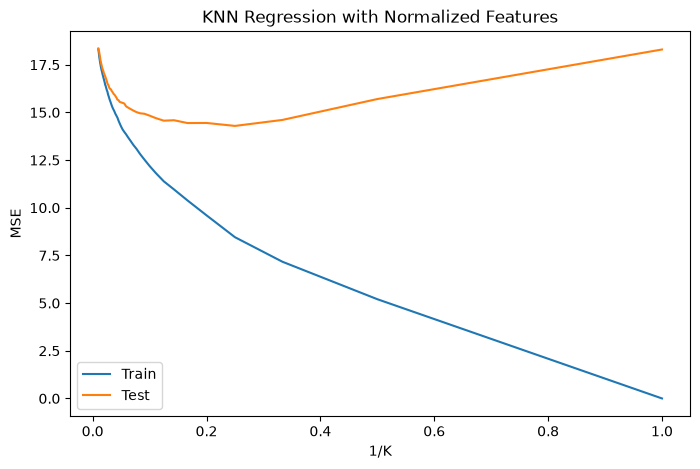

In [65]:
plt.figure(figsize=(8, 5))

plt.plot(inverse_k, train_errors_scaled, label="Train")
plt.plot(inverse_k, test_errors_scaled, label="Test")

plt.xlabel("1/K")
plt.ylabel("MSE")
plt.title("KNN Regression with Normalized Features")
plt.legend()
plt.show()

The best K is 5 for raw features and 4 for normalized features. Normalization lowers the test MSE from 15.727 to 14.291, improving KNN performance on this split. Features are normalized using MinMaxScaler fitted on the training data only. The same transformation is then applied to the test data.

### (j ) Compare KNN and Linear

Normalized KNN with K = 4 has the lowest test MSE of 14.291, compared with 15.727 for raw KNN and 18.660 for the regression model with quadratic and interaction terms. KNN performs better on this split, suggesting that local patterns help predict PE. However, the test set was also used to choose K, so the KNN results may be optimistic.

## 2. ISLR: 2.4.1

### (a) The sample size n is extremely large, and the number of predictors p is small.

A flexible method would generally perform better. With many observations and few predictors, there is enough data to learn a more complex relationship with less risk of overfitting.

### (b) The number of predictors p is extremely large, and the number of observations n is small.

A flexible method would generally perform worse. With many predictors and few observations, it is more likely to overfit the training data.

### (c) The relationship between the predictors and response is highly non-linear.

A flexible method would generally perform better because it can capture the highly nonlinear relationship more closely.

### (d) The variance of the error terms, i.e. $σ^2$ = Var(ε), is extremely high.

A flexible method would generally perform worse because it may fit the noise rather than the underlying relationship, leading to poorer predictions on new data.

## 3. ISLR: 2.4.7

### (a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0.

In [66]:
points = [
    [0, 3, 0],
    [2, 0, 0],
    [0, 1, 3],
    [0, 1, 2],
    [-1, 0, 1],
    [1, 1, 1]
]

for i in range(6):
    point = points[i]

    distance = (point[0] ** 2 + point[1] ** 2 + point[2] ** 2) ** 0.5

    print("Observation", i + 1, "Distance:", round(distance, 3))

Observation 1 Distance: 3.0
Observation 2 Distance: 2.0
Observation 3 Distance: 3.162
Observation 4 Distance: 2.236
Observation 5 Distance: 1.414
Observation 6 Distance: 1.732


The observations ordered from nearest to farthest are 5, 6, 2, 4, 1, and 3.

### (b) What is our prediction with K = 1? Why?

The prediction is Green because the nearest neighbor is observation 5, which is Green.

### (c) What is our prediction with K = 3? Why?

 The prediction is Red because the three nearest neighbors are observations 5, 6, and 2. Two are Red and one is Green.

### (d) If the Bayes decision boundary in this problem is highly non-linear, then would we expect the best value for K to be large or small? Why?

We would expect a small K because it allows a more flexible decision boundary that can capture nonlinear patterns. A large K would produce a smoother boundary and may miss these patterns.